# Geometric Brownian Motion

**Geometric Brownian motion** is the standard model for a price.

The idea is simple. An ordinary random walk *adds* a random amount each moment, which means it can wander below 0 -- fine for a temperature, wrong for a stock. Geometric Brownian motion *multiplies* by a random factor instead. Two things follow:

- It can **never reach 0**, because multiplying a positive number by a positive factor stays positive.
- Swings are **proportional to the current value**. A \$100 stock moves in dollars; a \$1 stock moves in cents. That matches how real prices behave -- a 2% move means the same thing at any price.

It has three settings:

| Setting | Meaning |
|---|---|
| `initial_value` | the price at time 0 |
| `growth_rate` | average growth per unit of time (`0.05` is about 5%) |
| `scale` | volatility -- how wildly it swings |


In [1]:
from symbulate import *
import numpy as np

## Draw a path

One draw is a whole path, a function of time. Ask it about any time `t >= 0`. Every path starts at `initial_value` exactly.

In [2]:
stock = GeometricBrownianMotion(
    initial_value=100,
    growth_rate=0.05,
    scale=0.3,
)
path = stock.draw()
[round(float(path(t)), 2) for t in [0, 1, 2, 5, 10]]

[100.0, 89.28, 118.12, 87.6, 64.97]

## Simulate and plot sample paths

All of them start at 100 and stay above 0. Notice they fan out *upward* more than downward -- a price can double many times over, but it can only ever fall by 100%.

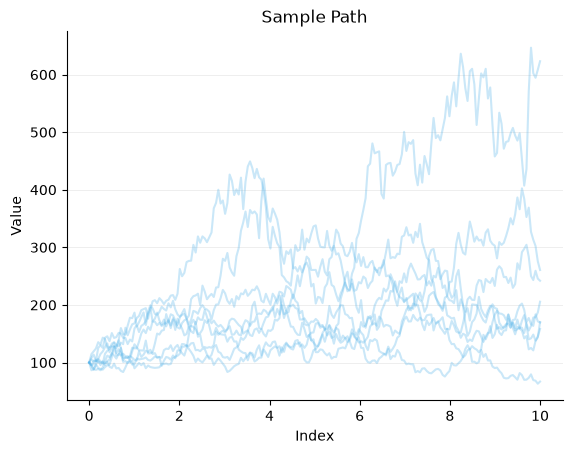

In [3]:
stock.sim(8).plot(tmin=0, tmax=10)

## Compare with ordinary Brownian motion

Here is the same setup -- start at 100, drift upward -- but with a process that **adds** a random amount instead of multiplying. Several paths sink straight through 0 and finish negative, which is nonsense for a price. That is the problem geometric Brownian motion solves.

(`BrownianMotion` always starts at 0, so `100 + ...` shifts it up to match the stock above.)

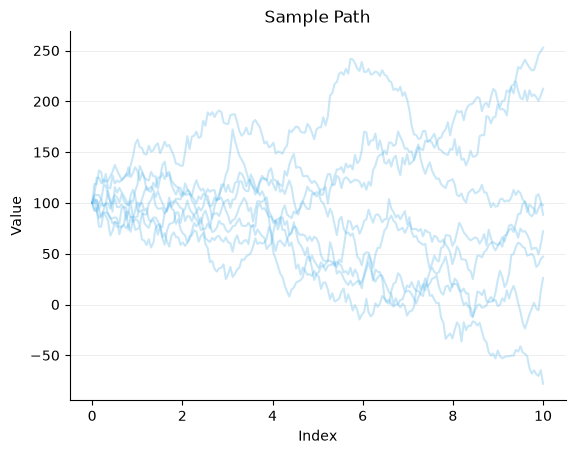

In [4]:
(100 + BrownianMotion(drift=5, scale=30)).sim(8).plot(tmin=0, tmax=10)

## `growth_rate` is the growth of the *average*

The average price at time `t` is exactly

$$\text{initial\_value} \times e^{\text{growth\_rate} \times t}$$

So after 10 years our stock should average `100 * exp(0.05 * 10)` = about 164.9.

In [5]:
simulated = stock[10.0].sim(4000).mean()
formula = 100 * np.exp(0.05 * 10)
round(float(simulated), 2), round(float(formula), 2)

(171.88, 164.87)

With `growth_rate=0` the average stays flat. The paths still move around plenty -- it is only the *average* that holds still.

In [6]:
flat = GeometricBrownianMotion(initial_value=100, growth_rate=0, scale=0.3)
round(float(flat[10.0].sim(4000).mean()), 2)

98.14

## `scale` is the volatility

A calm stock and a wild one, same growth rate. Watch the y-axis: the calm one stays in a narrow band, the wild one covers a huge range.

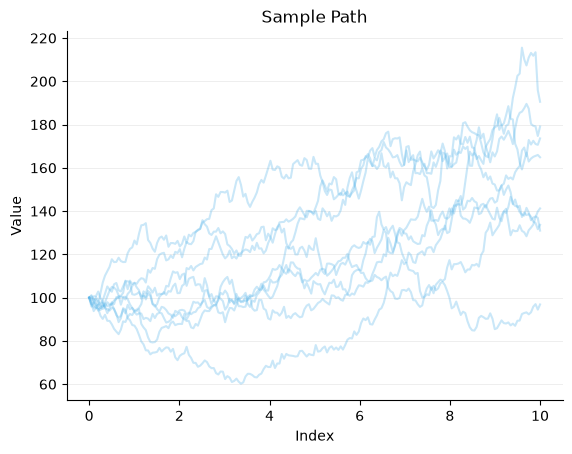

In [7]:
GeometricBrownianMotion(
    initial_value=100, growth_rate=0.05, scale=0.1
).sim(8).plot(tmin=0, tmax=10)

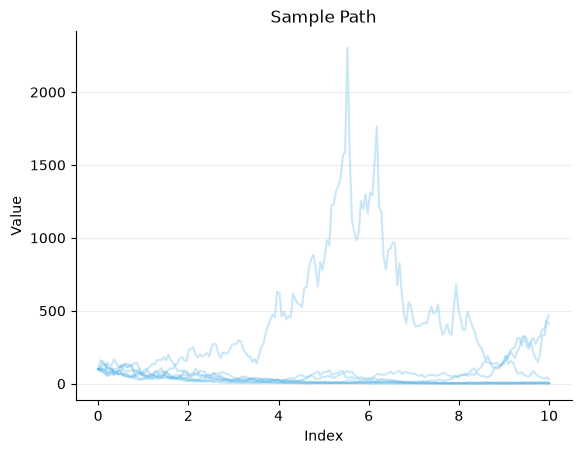

In [8]:
GeometricBrownianMotion(
    initial_value=100, growth_rate=0.05, scale=0.8
).sim(8).plot(tmin=0, tmax=10)

## The price at a fixed time

The price at one particular time is a random variable. Write `X[t]` to get it, then plot or summarize it like anything else.

The shape is **lop-sided**: a long tail stretching to the right. That is what "multiplying" produces, and it is called a *log-normal* distribution -- take the log and you get an ordinary bell curve.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


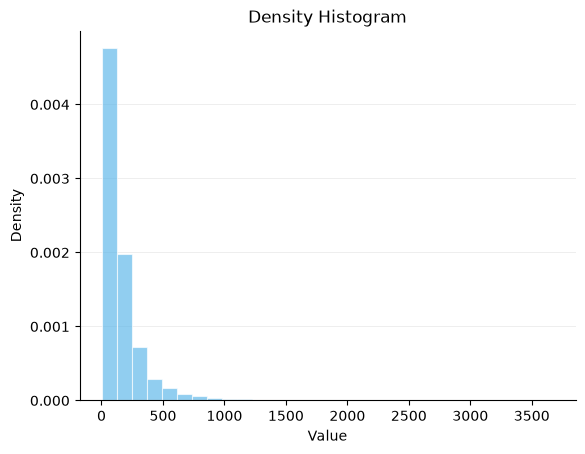

In [9]:
stock[10.0].sim(2000).plot()

Here is that claim checked. Taking the log of the price and dividing out the start gives a normal distribution, so its histogram is a plain bell curve:

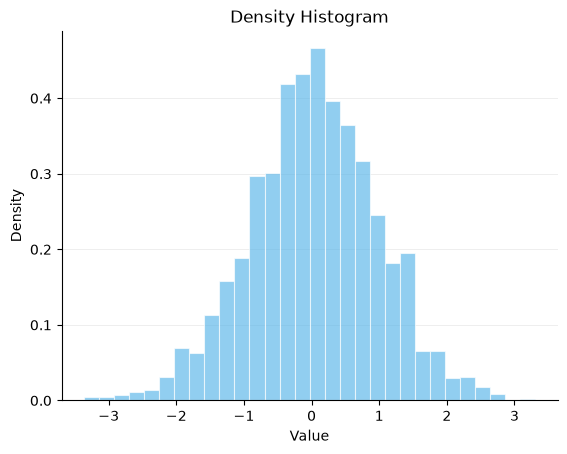

In [10]:
log_price = stock[10.0].apply(lambda price: np.log(price / 100))
log_price.sim(2000).plot()

## A surprise worth knowing: average up, typical down

Because the shape is lop-sided, the *average* and the *typical* path can go in opposite directions. The average is dragged upward by a few rare paths that get enormously rich, while most paths quietly shrink.

This happens whenever `growth_rate` is below `scale**2 / 2`. Below, `growth_rate` is 0.01 and `scale**2 / 2` is 0.125, so after 10 years:

- the average is **above** the starting 100 (in theory `100 * exp(0.01 * 10)` = 110.5, though the simulated average bounces around a lot -- it is being set by a handful of huge values)
- the **median** is about 32, and most paths have lost money

It is the real reason a volatile investment can have a great average return and still ruin most of the people who hold it.

In [11]:
risky = GeometricBrownianMotion(initial_value=100, growth_rate=0.01, scale=0.5)
outcomes = np.array(list(risky[10.0].sim(4000)), dtype=float)

print(f"average price:        {outcomes.mean():8.2f}")
print(f"median  price:        {np.median(outcomes):8.2f}")
print(f"fraction that lost money: {(outcomes < 100).mean():.1%}")

average price:          107.44
median  price:           32.00
fraction that lost money: 76.0%


## Zooming in shows more of the *same* path

A path is not a fixed list of numbers. Ask about a time in between two it already knows, and it fills in the gap in a way that agrees with both neighbours -- it does not start a new path. So values you have already seen never change.

In [12]:
check = stock.draw()
before = float(check(1.0)), float(check(2.0))

for t in [1.1, 1.25, 1.5, 1.75, 1.9]:
    check(t)

after = float(check(1.0)), float(check(2.0))
before == after

True

## Two more things

**It is simulated exactly.** There is no approximation and no step size to tune. A price path is built by taking a Brownian motion path and applying a formula to it:

$$\text{price}(t) = \text{initial\_value} \times e^{(\text{growth\_rate} - \text{scale}^2/2)\,t \;+\; \text{scale}\,W(t)}$$

The Brownian motion doing the work is available as `path.brownian_path`, if you want to look at it.

The `- scale**2 / 2` is the only fiddly bit. It is there so that `growth_rate` means the growth of the average price. Leave it out and the average would grow faster than the number you asked for.

**Time starts at 0.** Asking for a negative time raises an error, since the path begins at `initial_value` at time 0.

In [13]:
same = check.brownian_path
print(f"Brownian motion at t=2: {float(same(2.0)):.4f}")
print(f"price          at t=2: {float(check(2.0)):.4f}")
print(
    f"formula          gives: "
    f"{100 * np.exp((0.05 - 0.3**2 / 2) * 2 + 0.3 * float(same(2.0))):.4f}"
)

Brownian motion at t=2: -0.0316
price          at t=2: 100.0511
formula          gives: 100.0511
